# Astrometric Plate Solve — Interactive Dev

Paired with `astrometric_dev.py`.  Edit the `.py` file, re-run any cell — `%autoreload 2` reloads without a kernel restart.

**Workflow:**
1. Configure backend and hints
2. Solve the simulated image (`testsim.fits`)
3. Inspect result, WCS, and rotation angle
4. Solve the real image (`fuji6_asi178_100_15s.fit`) with coordinate/scale hints
5. Compare header values vs solver output

**Backends:**
- `local`      — astrometry.net `solve-field` (Linux/WSL2).  Needs index files.
- `astroquery` — nova.astrometry.net online API.  Needs a free API key; ~1 min per solve.

In [8]:
# Cell 1 — bootstrap
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

root = next(p for p in Path(".").resolve().parents if (p / "sim").is_dir())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f"Project root: {root}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: C:\Users\bassd\Research\Drone\tele-img-sim


In [19]:
# Cell 2 — imports and solver configuration
import numpy as np
import matplotlib.pyplot as plt
import astrometric_dev as adev

# --- file paths ---
FITS_SIM  = root / "data" / "testsim.fits"
FITS_REAL = root / "data" / "fuji6_asi178_100_15s.fit"
FITS_M81 = root / "data" / "m81.fits"

# --- backend selection ---
# Change backend="astroquery" and set your API key if solve-field is not installed.
# On Windows without WSL: use backend="astroquery".
# On WSL2: set solve_field_bin="wsl solve-field"

CFG = adev.PlateSolveConfig(
    backend             = "astroquery",
    #solve_field_bin     = "solve-field",   # or "wsl solve-field" for WSL2
    timeout_s           = 120,
    search_radius_deg   = 5.0,
    downsample          = 2,
    api_key           = "lwjnpipyuogouebl",  # only for backend="astroquery"
)

print("Config:", CFG)

Config: PlateSolveConfig(backend='astroquery', solve_field_bin='solve-field', timeout_s=120, ra_deg=None, dec_deg=None, search_radius_deg=5.0, scale_low_arcsec_per_px=None, scale_high_arcsec_per_px=None, api_key='lwjnpipyuogouebl', downsample=2, extra_args=[])


## Part A — Simulated image (`testsim.fits`)

The simulated FITS header already contains `RA0`, `DEC0`, `ROT`, and `PLTSCL`.  `solve_field` will promote these to search hints automatically.  After solving we compare the solver's answer to the ground-truth header values.

Shape : (3672, 5496)
dtype : float32
Range : [-0.0, 280316.8]
Header RA0 : None
Header DEC0: None
Header ROT : None
Header PLTSCL: None arcsec/px


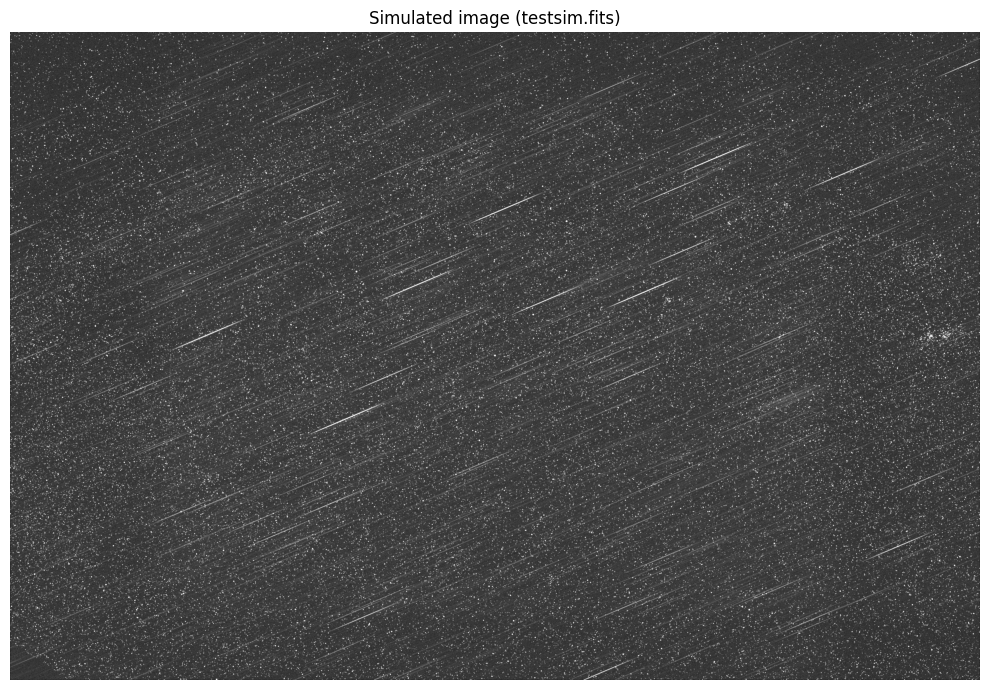

In [10]:
# Cell 3 — load and display simulated image
sim_data, sim_header = adev.load_fits(FITS_SIM)
print(f"Shape : {sim_data.shape}")
print(f"dtype : {sim_data.dtype}")
print(f"Range : [{sim_data.min():.1f}, {sim_data.max():.1f}]")
print(f"Header RA0 : {sim_header.get('RA0')}")
print(f"Header DEC0: {sim_header.get('DEC0')}")
print(f"Header ROT : {sim_header.get('ROT')}")
print(f"Header PLTSCL: {sim_header.get('PLTSCL')} arcsec/px")

adev.show_image(sim_data, title="Simulated image (testsim.fits)", stretch="asinh")

Solving...................................................................................................Status : FAILED
Messages:
  Submitting 300 pre-detected sources to nova.astrometry.net
  astroquery error: ('Solve timed out without success or failure', 14835125)


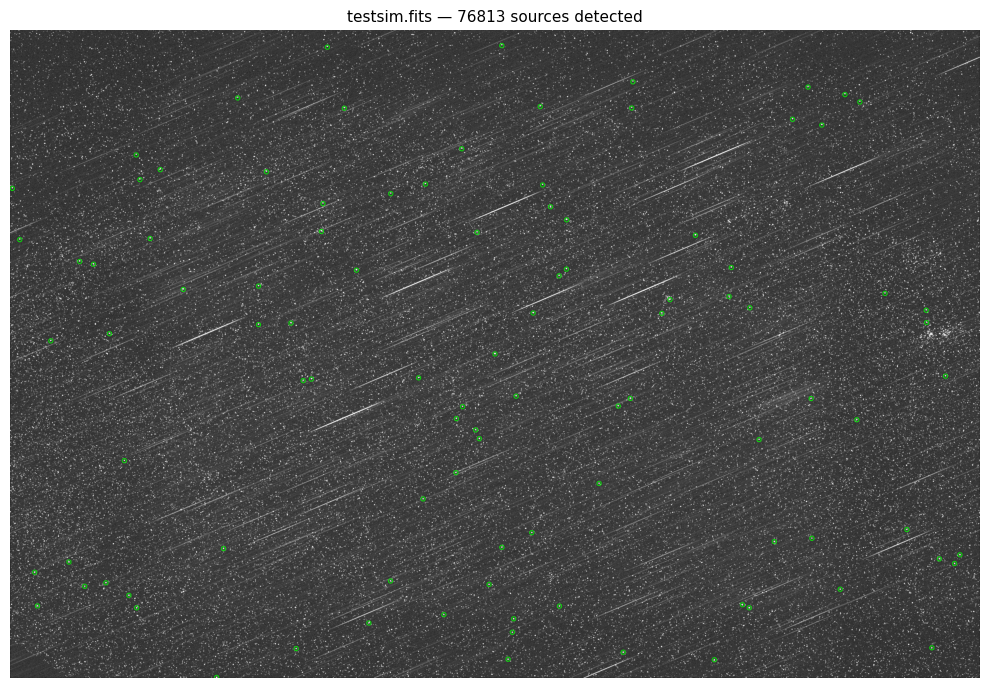

In [13]:
# Cell 4 — solve the simulated image
# Hints are auto-extracted from the header (RA0, DEC0, PLTSCL).
# You can also pass ra_deg=, dec_deg=, scale_arcsec_per_px= here to override.

sim_result = adev.solve_field(FITS_SIM, CFG)
adev.summarize_result(sim_result)

In [14]:
# Cell 5 — if the solve failed, inspect subprocess output
# Comment this cell out once the solve is working.
if not sim_result.success:
    adev.show_debug_info(sim_result)

── stdout ────────────────────────────────────────────────────────────
(empty)
── stderr ────────────────────────────────────────────────────────────
(empty)
── returncode: None ───────────────────────────────────────────────


In [15]:
# Cell 6 — load WCS and extract rotation angle
sim_wcs = adev.load_wcs(sim_result)

if sim_wcs is not None:
    rot = adev.extract_rot_deg(sim_wcs)
    print(f"Detector rotation from WCS : {rot:.4f}°")
    print(f"Header ROT (ground truth)  : {sim_header.get('ROT')}°")
    print(f"Residual                   : {rot - float(sim_header.get('ROT', 0)):.4f}°")
else:
    print("No WCS available (solve failed).")

No WCS available (solve failed).


In [ ]:
# Cell 7 — display image with WCS sky-coordinate grid
if sim_wcs is not None:
    adev.show_image(
        sim_data,
        wcs=sim_wcs,
        title="Simulated image — solved WCS overlay",
        stretch="asinh",
        figsize=(10, 8),
    )
else:
    print("Skipped — no WCS.")

In [ ]:
# Cell 8 — compare header hints vs solved values
adev.compare_header_vs_solved(sim_result, sim_header)

## Part B — Real image (`fuji6_asi178_100_15s.fit`)

Provide approximate coordinates and pixel scale as hints if the header does not carry them.  Adjust `REAL_RA`, `REAL_DEC`, and `REAL_SCALE_ARCSEC_PX` below to match your target field.

Shape : (3520, 4656)
Range : [1296.0, 63840.0]
  RA          : 148.867743065167
  DEC         : 69.0777925531915
  FOCALLEN    : 344.0


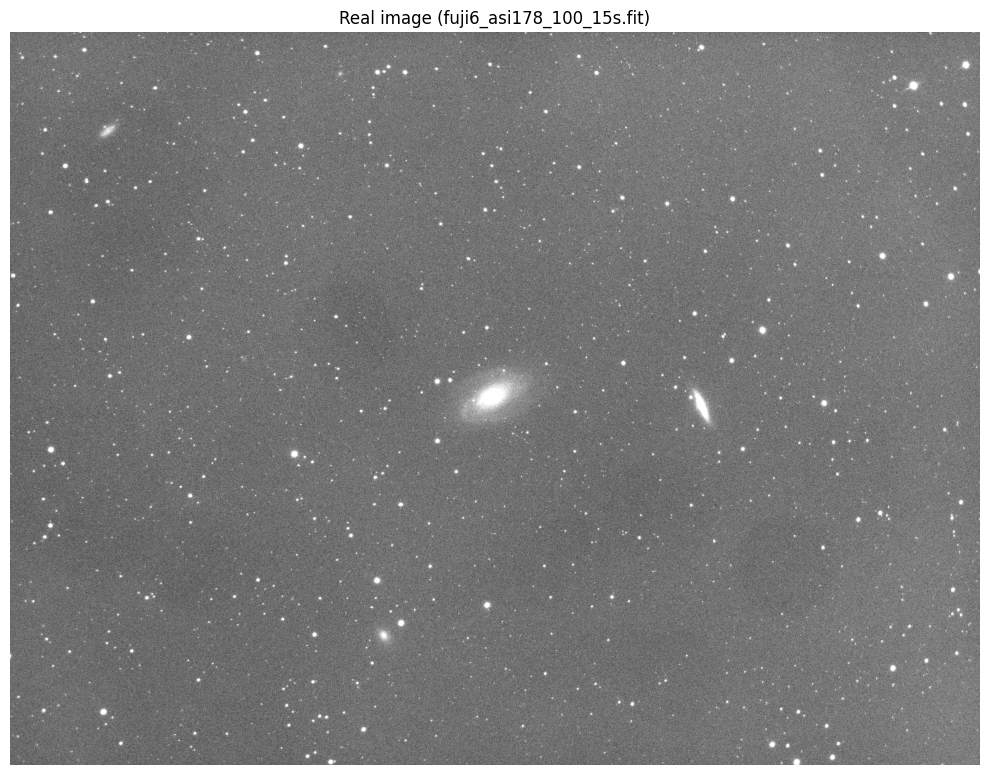

In [20]:
# Cell 9 — load real image
real_data, real_header = adev.load_fits(FITS_M81)
print(f"Shape : {real_data.shape}")
print(f"Range : [{real_data.min():.1f}, {real_data.max():.1f}]")

# Print any WCS-relevant header keywords that are present
for k in ("RA", "RA0", "CRVAL1", "DEC", "DEC0", "CRVAL2", "ROT", "ROLL", "PLTSCL", "PIXSCL", "FOCALLEN", "PIXSIZE"):
    if k in real_header:
        print(f"  {k:12s}: {real_header[k]}")

adev.show_image(real_data, title="Real image", stretch="asinh")

Solving.............Status : SOLVED
RA     : 150.36715°
Dec    : 69.18965°
Rot    : 88.1217°
Messages:
  Submitting 300 pre-detected sources to nova.astrometry.net
  Solved: RA=150.36715°  Dec=69.18965°  rot=88.122°


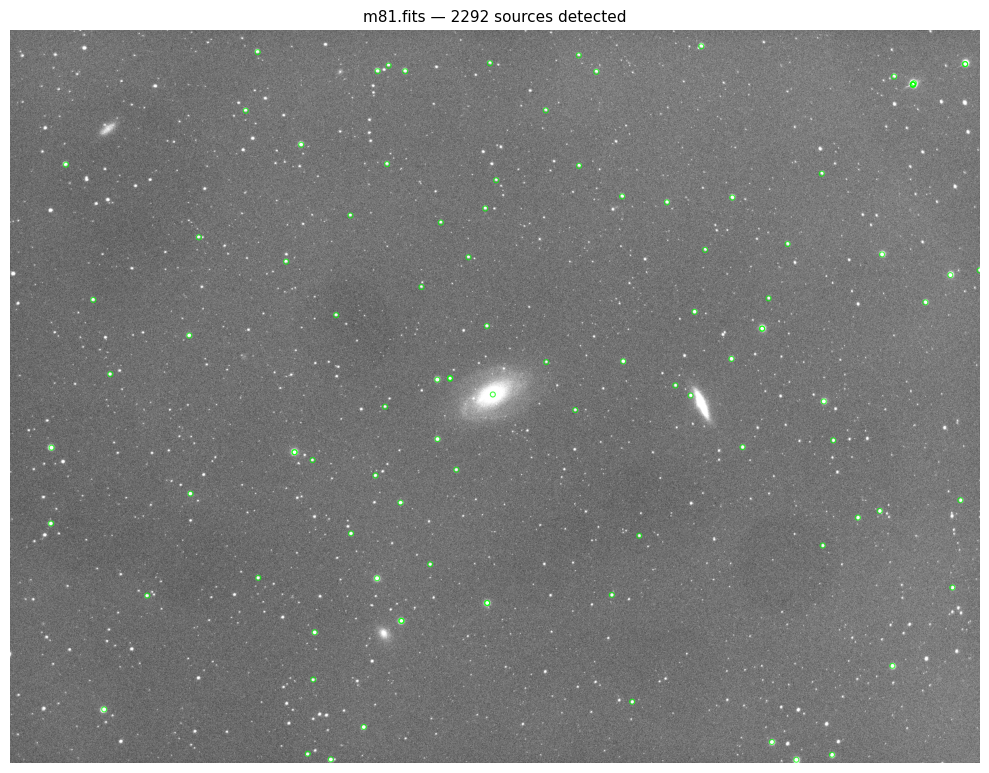

In [22]:
# Cell 10 — solve real image
# Set approximate coordinates and pixel scale.  These are only search hints;
# the solver finds the exact solution.  scale_tolerance=0.25 means ±25%.

REAL_RA              = None   # degrees — set to approximate field centre
REAL_DEC             = None   # degrees
REAL_SCALE_ARCSEC_PX = None   # arcsec/pixel — e.g. 2.5 for a typical setup
REAL_SCALE_TOLERANCE = 0.25   # ±25% around the hint

real_result = adev.solve_field(
    FITS_M81,
    CFG,
    ra_deg              = REAL_RA,
    dec_deg             = REAL_DEC,
    scale_arcsec_per_px = REAL_SCALE_ARCSEC_PX,
    scale_tolerance     = REAL_SCALE_TOLERANCE,
)
adev.summarize_result(real_result)

In [23]:
# Cell 11 — debug real solve if needed
if not real_result.success:
    adev.show_debug_info(real_result)

Detector rotation : 88.1217°


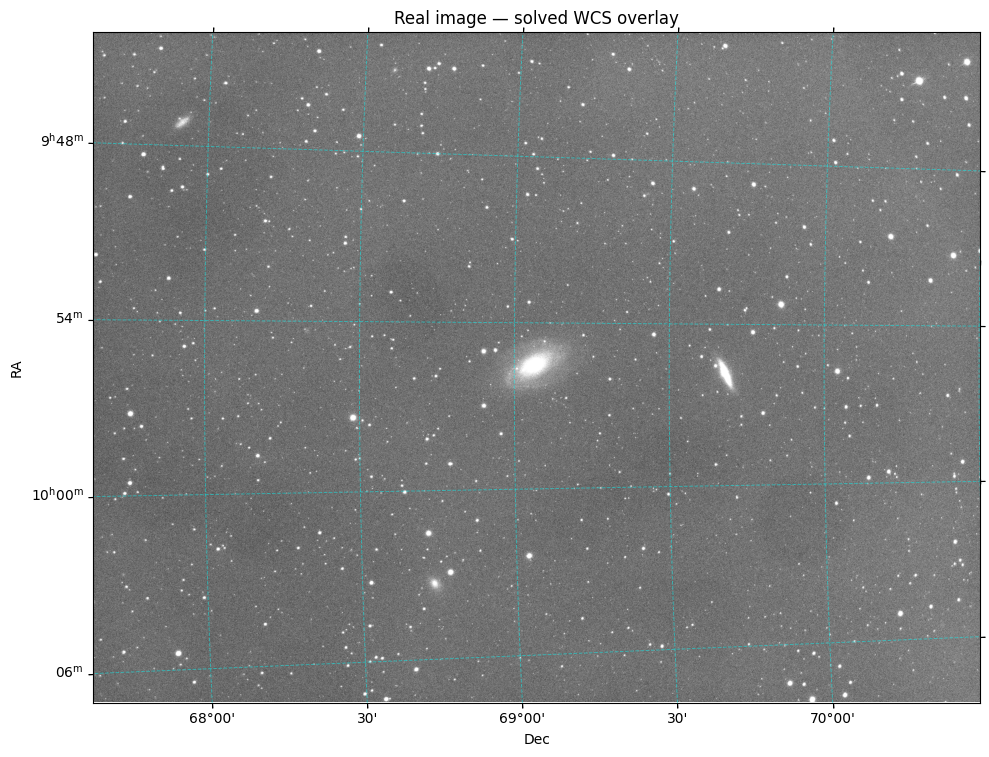

                           Header           Solved
──────────────────────────────────────────────────
RA                     148.86774°       150.36715°
Dec                     69.07779°        69.18965°
Rot                             —        88.12172°
Plate scale                     —       (from WCS)


In [24]:
# Cell 12 — rotation from real solve
real_wcs = adev.load_wcs(real_result)

if real_wcs is not None:
    rot_real = adev.extract_rot_deg(real_wcs)
    print(f"Detector rotation : {rot_real:.4f}°")
    adev.show_image(
        real_data,
        wcs=real_wcs,
        title="Real image — solved WCS overlay",
        stretch="asinh",
    )
    adev.compare_header_vs_solved(real_result, real_header)
else:
    print("No WCS — solve failed or not yet run.")

## Tuning guide

| Problem | What to try |
|---|---|
| `solve-field not found` | Install astrometry.net or use `backend="astroquery"` |
| No index files | `apt install astrometry.net-data-*` or download from http://data.astrometry.net |
| Solve fails with hints | Widen `search_radius_deg` or `scale_tolerance` |
| Solve too slow | Add tighter scale/ra/dec hints; increase `downsample` |
| Wrong rotation sign | Check `extract_rot_deg` convention vs your simulator's `rot_deg` |
| WSL2 path issues | See `PlateSolveConfig.solve_field_bin` docs in `astrometric_dev.py` |

## Next step: port to `measure/platesolve.py`

Once results look correct:
1. Move `PlateSolveConfig` → `measure/types.py`
2. Replace the stub body of `run_platesolve` in `measure/platesolve.py` with `_solve_local` / `_solve_astroquery`
3. Wire `_hints_from_header` into `MeasurementMetadata.from_header`
4. Keep notebook helpers in this `dev/` module or move to `measure/display.py`
5. Run `measurement.ipynb` end-to-end to verify `MeasurementMetrics.astrometric_rot_deg` is populated